# Step 2.3: Shape Graph批量处理与验证

## 目标

1. 批量处理多个帧的Shape Graph构建
2. 分析Shape Graph的时序稳定性
3. 验证图表示的鲁棒性
4. 保存批量处理结果

## 1. 导入库和配置

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import networkx as nx
import heapq
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from goalkeeper_identifier import identify_goalkeeper, separate_players_and_ball

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 比赛信息
GAME_ID = 10517  # 2022世界杯决赛 (Argentina vs France)
HOME_TEAM_ID = '364'  # 阿根廷 (Argentina)
AWAY_TEAM_ID = '363'  # 法国 (France)

# Shape Graph参数
ALPHA_THRESHOLD = 3 * np.pi / 4  # 135度角度稳定性阈值
NUM_FRAMES = None  # None表示处理所有帧，或指定数字如100  # 批量处理的帧数

# 数据路径
DATA_DIR = Path('../../data/morph_test')
INPUT_FILE = DATA_DIR / f'tracking_data_{GAME_ID}_scaled.parquet'
OUTPUT_DIR = DATA_DIR / 'shape_graphs'
GRAPHS_DIR = OUTPUT_DIR / 'graphs'
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"配置完成")
print(f"比赛: 2022世界杯决赛 (Game {GAME_ID})")
print(f"分析球队: 阿根廷 (Team ID: {HOME_TEAM_ID})")
print(f"将处理 {NUM_FRAMES} 帧数据")

配置完成
比赛: 2022世界杯决赛 (Game 10517)
分析球队: 阿根廷 (Team ID: 364)
将处理 None 帧数据


## 2. 加载数据

In [ ]:
tracking_pl = pl.read_parquet(INPUT_FILE)

period_1_frames = tracking_pl.filter(pl.col('period_id') == 1)['frame_id'].unique().sort()   #仅处理第一节的帧数据

# 根据NUM_FRAMES参数决定处理帧数
if NUM_FRAMES is None:
    sample_frames = period_1_frames  # 处理第一节的所有帧
    print(f"将处理第一节的所有帧")
else:
    sample_frames = period_1_frames[:NUM_FRAMES]  # 处理指定数量的帧
    print(f"将处理前{NUM_FRAMES}帧")

print(f"加载完成: {len(sample_frames)} 帧")
print(f"帧范围: {sample_frames[0]} - {sample_frames[-1]}")

将处理第一节的所有帧
加载完成: 50084 帧
帧范围: 4630 - 98893


## 3. 核心函数定义

In [3]:
def compute_angle(p, q, r):
    """计算角度 ∠prq (以r为顶点)"""
    v1 = p - r
    v2 = q - r
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.arccos(cos_angle)

def compute_opposing_angle(p_idx, q_idx, face_vertices, positions):
    """计算边(p,q)在给定面中的对立角"""
    p = positions[p_idx]
    q = positions[q_idx]
    other_vertices = [v for v in face_vertices if v != p_idx and v != q_idx]
    if len(other_vertices) == 0:
        return 0.0
    min_angle = np.pi
    for r_idx in other_vertices:
        r = positions[r_idx]
        angle = compute_angle(p, q, r)
        min_angle = min(min_angle, angle)
    return min_angle

def build_initial_graph(positions):
    """构建初始Delaunay三角剖分图"""
    tri = Delaunay(positions)
    edge_to_faces = defaultdict(list)
    
    for simplex in tri.simplices:
        for i in range(3):
            p1 = simplex[i]
            p2 = simplex[(i + 1) % 3]
            edge = tuple(sorted([p1, p2]))
            edge_to_faces[edge].append(list(simplex))
    
    return tri, edge_to_faces

def build_shape_graph(positions, alpha_threshold=ALPHA_THRESHOLD, verbose=False):
    """构建Shape Graph"""
    tri, edge_to_faces = build_initial_graph(positions)
    priority_queue = []
    edge_stability = {}
    
    for edge, faces in edge_to_faces.items():
        p_idx, q_idx = edge
        alpha_pq = 0.0
        alpha_qp = 0.0
        if len(faces) >= 1:
            alpha_pq = compute_opposing_angle(p_idx, q_idx, faces[0], positions)
        if len(faces) >= 2:
            alpha_qp = compute_opposing_angle(q_idx, p_idx, faces[1], positions)
        stability = alpha_pq + alpha_qp
        edge_stability[edge] = stability
        heapq.heappush(priority_queue, (-stability, edge))
    
    removed_edges = []
    
    while priority_queue:
        neg_stability, edge = heapq.heappop(priority_queue)
        stability = -neg_stability
        if stability <= alpha_threshold:
            break
        if edge not in edge_to_faces:
            continue
        removed_edges.append(edge)
        edge_to_faces.pop(edge)
    
    shape_graph = nx.Graph()
    for i, pos in enumerate(positions):
        shape_graph.add_node(i, x=float(pos[0]), y=float(pos[1]))
    for edge in edge_to_faces.keys():
        p_idx, q_idx = edge
        dist = np.linalg.norm(positions[p_idx] - positions[q_idx])
        shape_graph.add_edge(p_idx, q_idx, distance=dist)
    
    return shape_graph, len(removed_edges), len(edge_to_faces) + len(removed_edges)

print("核心函数定义完成")

核心函数定义完成


## 4. 批量处理Shape Graph

In [4]:
# 批量处理Shape Graph（使用混合策略识别守门员）
# 注: 本notebook分析阿根廷队在2022世界杯决赛中的阵型
results = []

print("=== 开始批量处理 ===")
for frame_id in tqdm(sample_frames, desc="处理帧"):
    # 🔧 混合策略：为每一帧识别守门员
    goalkeeper_id = identify_goalkeeper(tracking_pl, HOME_TEAM_ID, frame_id=frame_id, method='statistical', quiet=True)
    
    # 分离外场球员、守门员和球
    field_players, goalkeeper, ball = separate_players_and_ball(
        tracking_pl, HOME_TEAM_ID, frame_id, goalkeeper_id
    )
    
    if len(field_players) < 3:
        continue
    
    positions = field_players[['x', 'y']].values
    shape_graph, num_removed, num_initial = build_shape_graph(positions)

    # 💾 保存Shape Graph结构（用于Step 3的凸包分解）
    import pickle
    graph_file = GRAPHS_DIR / f"shape_graph_{frame_id}.pkl"
    with open(graph_file, "wb") as f:
        pickle.dump({
            "frame_id": frame_id,
            "graph": shape_graph,
            "positions": positions,
            "field_players": field_players,  # 保存球员信息（已经是pandas DataFrame）
        }, f)
    
    results.append({
        'frame_id': frame_id,
        'num_players': len(positions),
        'num_initial_edges': num_initial,
        'num_removed_edges': num_removed,
        'num_final_edges': shape_graph.number_of_edges(),
        'removal_rate': num_removed / num_initial if num_initial > 0 else 0,
        'avg_degree': 2 * shape_graph.number_of_edges() / len(positions) if len(positions) > 0 else 0
    })

results_df = pd.DataFrame(results)
print(f"\n处理完成: {len(results_df)} 帧")
print(f"\n统计摘要:")
print(results_df.describe())

=== 开始批量处理 ===


处理帧: 100%|██████████| 50084/50084 [1:38:22<00:00,  8.49it/s]



处理完成: 50084 帧

统计摘要:
           frame_id  num_players  num_initial_edges  num_removed_edges  \
count  50084.000000      50084.0       50084.000000       50084.000000   
mean   51117.142441         10.0          20.819144           5.904920   
std    27830.319731          0.0           0.926225           1.612448   
min     4630.000000         10.0          18.000000           2.000000   
25%    27557.750000         10.0          20.000000           5.000000   
50%    54246.500000         10.0          21.000000           6.000000   
75%    75136.250000         10.0          21.000000           7.000000   
max    98893.000000         10.0          23.000000          11.000000   

       num_final_edges  removal_rate    avg_degree  
count     50084.000000  50084.000000  50084.000000  
mean         14.914224      0.282421      2.982845  
std           1.386247      0.071787      0.277249  
min          10.000000      0.095238      2.000000  
25%          14.000000      0.238095      2.80

## 4.1. Shape Graph保存信息

每帧的Shape Graph已保存为pickle文件，包含：
- `frame_id`: 帧ID
- `graph`: NetworkX图对象（包含节点位置和边连接）
- `positions`: 球员位置数组
- `field_players`: 球员详细信息（ID、坐标等）

In [5]:
# 显示保存的Shape Graph文件信息
import os

graph_files = list(GRAPHS_DIR.glob('shape_graph_*.pkl'))
print(f"\n=== Shape Graph保存信息 ===")
print(f"保存目录: {GRAPHS_DIR}")
print(f"文件数量: {len(graph_files)}")
print(f"文件格式: pickle (.pkl)")

if len(graph_files) > 0:
    # 计算总大小
    total_size = sum(os.path.getsize(f) for f in graph_files)
    print(f"总大小: {total_size / 1024 / 1024:.2f} MB")
    print(f"平均大小: {total_size / len(graph_files) / 1024:.2f} KB/文件")
    
    # 测试加载一个文件
    import pickle
    test_file = graph_files[0]
    with open(test_file, 'rb') as f:
        data = pickle.load(f)
    
    print(f"\n示例文件: {test_file.name}")
    print(f"  - 帧ID: {data['frame_id']}")
    print(f"  - 节点数: {data['graph'].number_of_nodes()}")
    print(f"  - 边数: {data['graph'].number_of_edges()}")
    print(f"  - 球员数: {len(data['positions'])}")
    print(f"\n✅ Shape Graph文件可以正常加载！")


=== Shape Graph保存信息 ===
保存目录: ..\..\data\morph_test\shape_graphs\graphs
文件数量: 50084
文件格式: pickle (.pkl)
总大小: 245.37 MB
平均大小: 5.02 KB/文件

示例文件: shape_graph_10018.pkl
  - 帧ID: 10018
  - 节点数: 10
  - 边数: 15
  - 球员数: 10

✅ Shape Graph文件可以正常加载！


## 5. 时序稳定性分析

## 5.5. 关键帧Shape Graph可视化

可视化几个代表性帧的Shape Graph结构

将可视化 6 个关键帧:
  帧1/6: 帧4630
  帧2/6: 帧19904
  帧3/6: 帧39683
  帧4/6: 帧64144
  帧5/6: 帧80583
  帧6/6: 帧98893


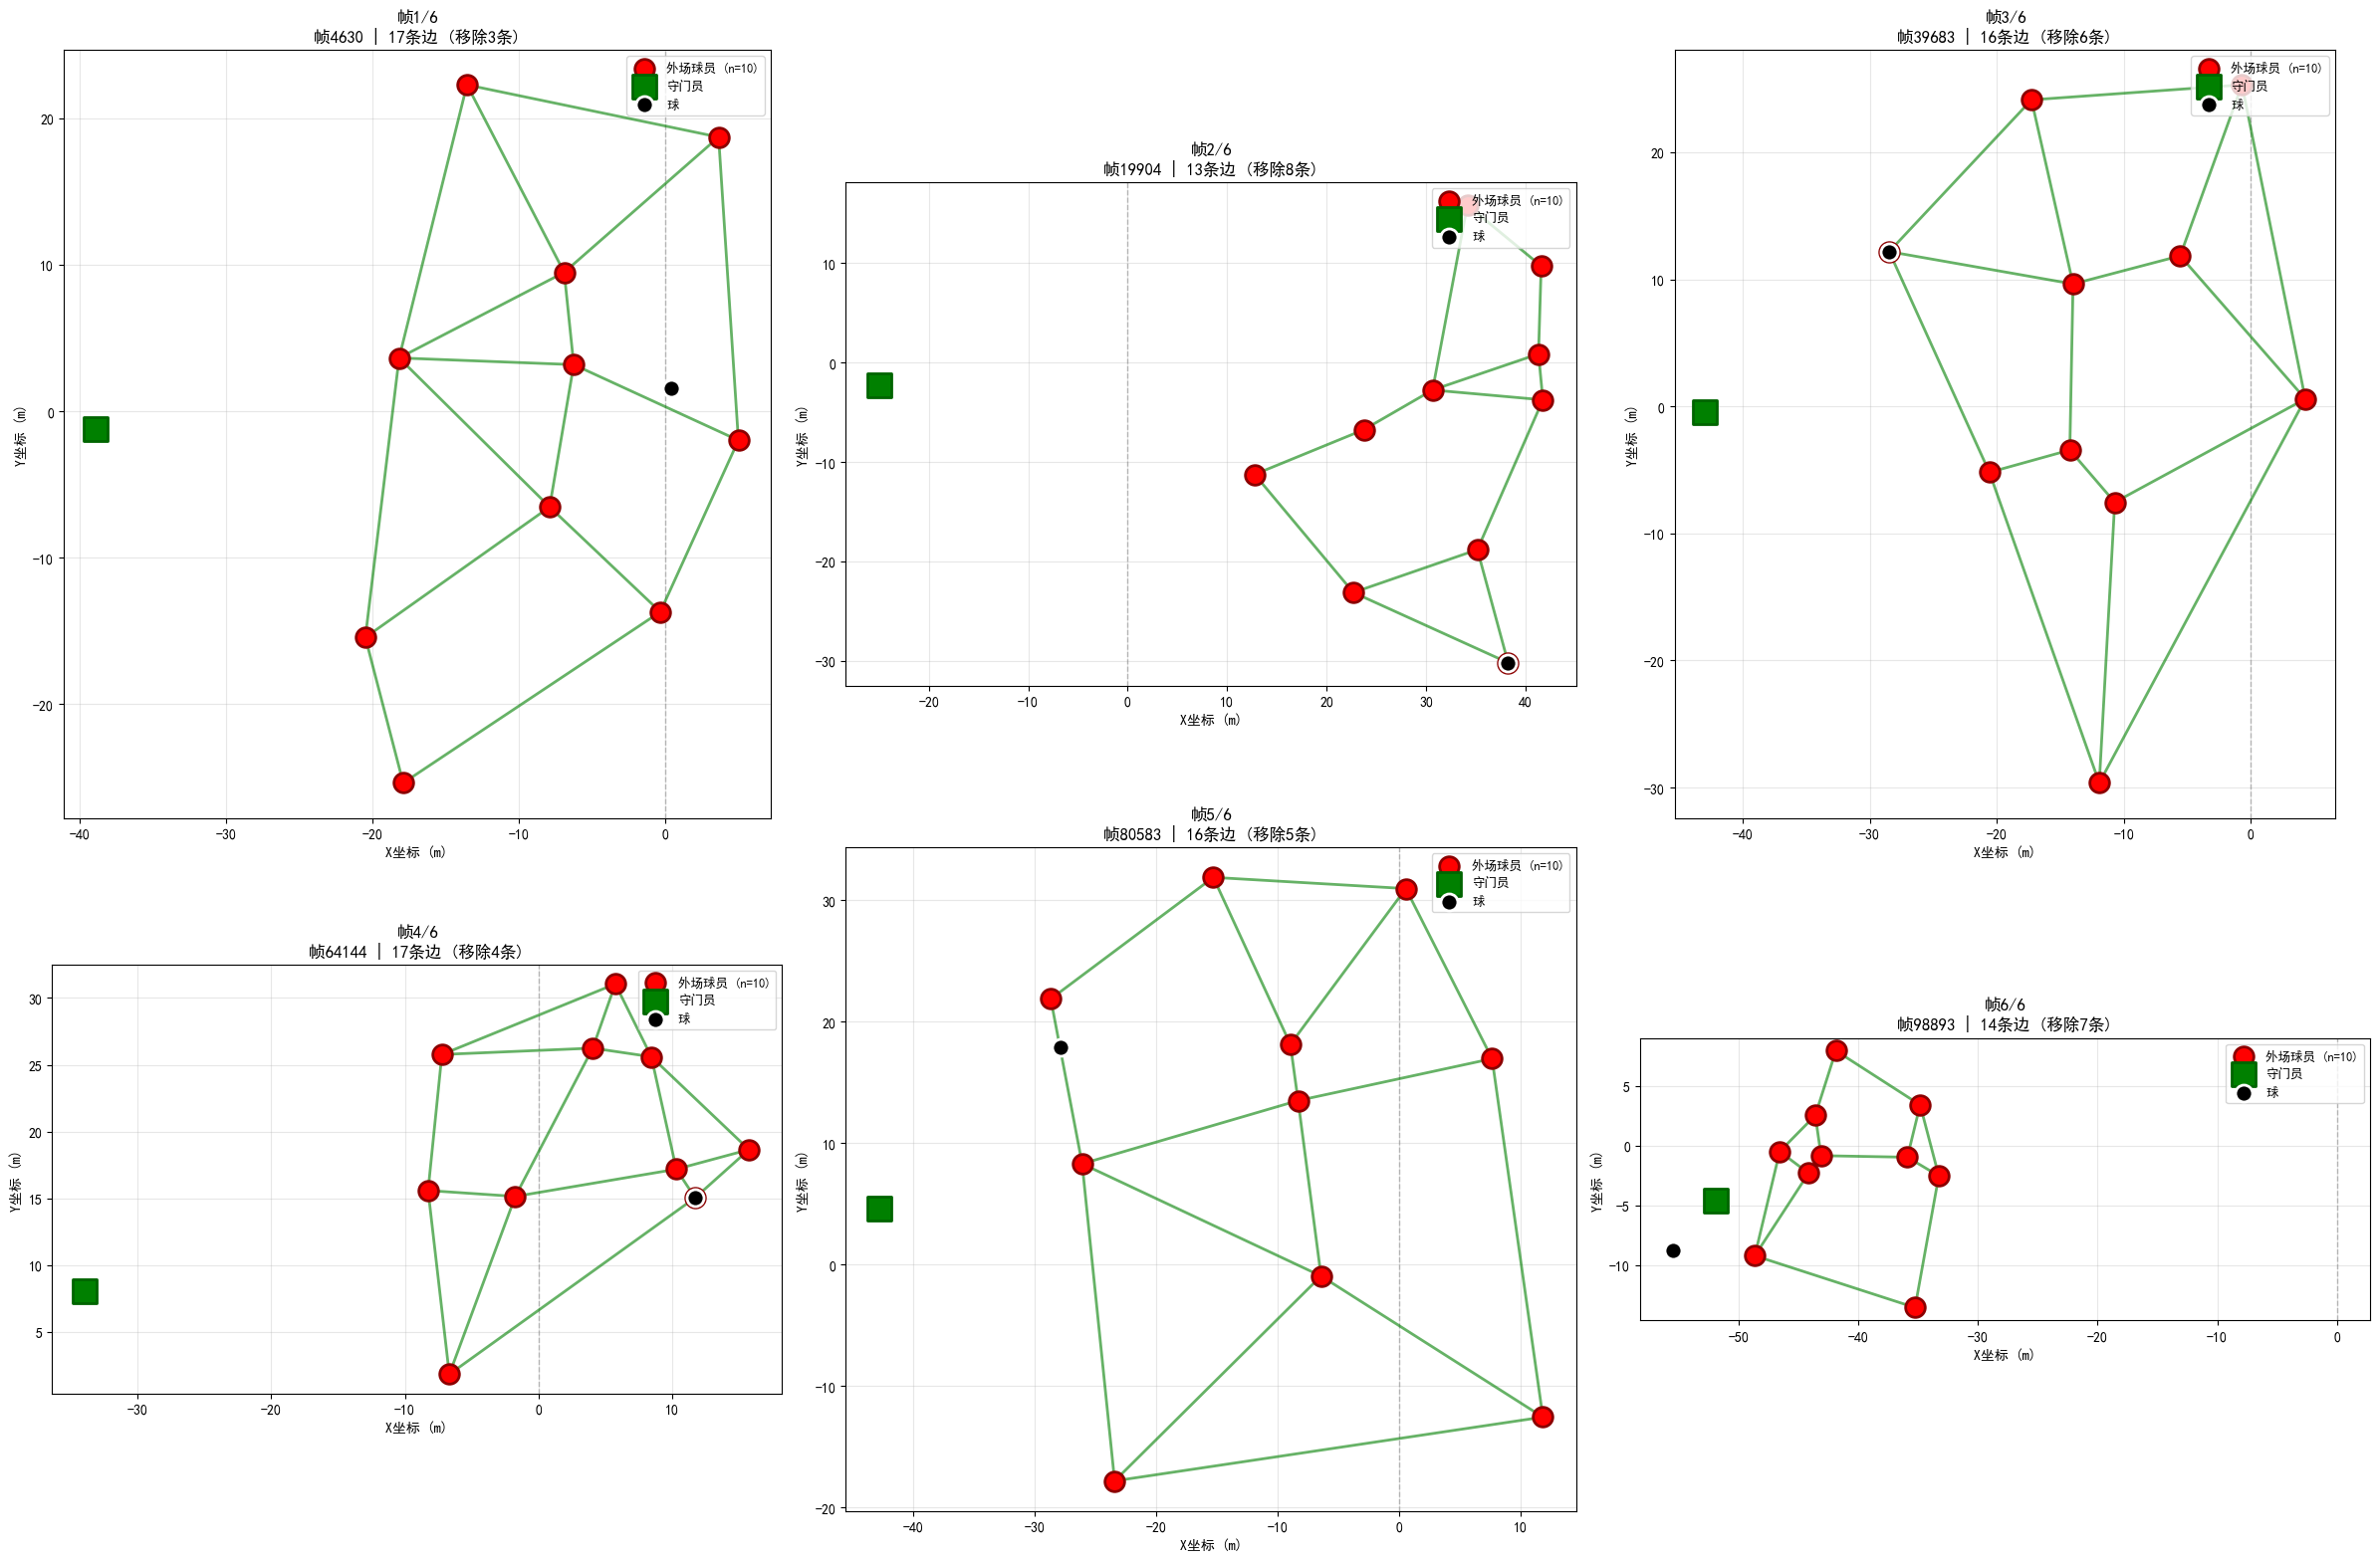


关键帧Shape Graph可视化完成！
- 🔴 红色圆点: 外场球员
- 🟢 绿色方块: 守门员
- ⚫ 黑色圆点: 球
- 绿色线条: Shape Graph的边

[TIP] 提示: 修改manual_frames变量可自定义要可视化的帧
   例如: manual_frames = [4630, 4700, 4800, 5000, 5200, 5400]


In [6]:
# 选择关键帧进行可视化
# 可自定义：直接指定帧ID列表，或使用自动选择

# 方法1：手动指定帧ID（推荐，可选择差异较大的帧）
# 例如：选择不同战术阶段的代表性帧
manual_frames = None  # 设置为None使用自动选择，或指定如: [4630, 4680, 4720, 5000, 5200, 5400]

# 方法2：自动选择（从整个序列中均匀采样）
if manual_frames is None:
    # 从整个帧序列中均匀选择6个代表性帧
    n_frames = min(6, len(sample_frames))
    if n_frames > 1:
        indices = [int(i * (len(sample_frames) - 1) / (n_frames - 1)) for i in range(n_frames)]
    else:
        indices = [0]
    key_frames = [(f'帧{i+1}/{n_frames}', sample_frames[idx]) for i, idx in enumerate(indices)]
else:
    key_frames = [(f'自定义帧{i+1}', fid) for i, fid in enumerate(manual_frames)]

print(f"将可视化 {len(key_frames)} 个关键帧:")
for label, fid in key_frames:
    print(f"  {label}: 帧{fid}")

# 创建子图
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

for idx, (label, frame_id) in enumerate(key_frames):
    if idx >= 6:
        break
    
    ax = axes[idx]
    
    # 识别守门员（静默模式）
    goalkeeper_id = identify_goalkeeper(tracking_pl, HOME_TEAM_ID, frame_id=frame_id, method='statistical', quiet=True)
    
    # 分离数据
    field_players, goalkeeper, ball = separate_players_and_ball(
        tracking_pl, HOME_TEAM_ID, frame_id, goalkeeper_id
    )
    
    if len(field_players) < 3:
        ax.text(0.5, 0.5, '数据不足', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # 构建Shape Graph
    positions = field_players[['x', 'y']].values
    shape_graph, num_removed, num_initial = build_shape_graph(positions)
    
    # 绘制Shape Graph的边
    for edge in shape_graph.edges():
        p1, p2 = edge
        ax.plot([positions[p1, 0], positions[p2, 0]], 
                [positions[p1, 1], positions[p2, 1]], 
                'g-', linewidth=2, alpha=0.6, zorder=3)
    
    # 外场球员（红色圆点）
    ax.scatter(positions[:, 0], positions[:, 1], 
               c='red', s=200, marker='o', edgecolors='darkred', linewidths=2,
               label=f'外场球员 (n={len(field_players)})', zorder=5)
    
    # 守门员（绿色方块）
    if len(goalkeeper) > 0:
        gk_pos = goalkeeper[['x', 'y']].values
        ax.scatter(gk_pos[:, 0], gk_pos[:, 1], 
                   c='green', s=300, marker='s', edgecolors='darkgreen', linewidths=2,
                   label='守门员', zorder=5)
    
    # 球（黑色圆点）
    if len(ball) > 0:
        ball_pos = ball[['x', 'y']].values
        ax.scatter(ball_pos[:, 0], ball_pos[:, 1], 
                   c='black', s=150, marker='o', edgecolors='white', linewidths=2,
                   label='球', zorder=6)
    
    ax.set_title(f'{label}\n帧{frame_id} | {shape_graph.number_of_edges()}条边 (移除{num_removed}条)', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlabel('X坐标 (m)', fontsize=10)
    ax.set_ylabel('Y坐标 (m)', fontsize=10)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# 隐藏多余的子图
for idx in range(len(key_frames), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'key_frames_shape_graphs.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n关键帧Shape Graph可视化完成！")
print("- 🔴 红色圆点: 外场球员")
print("- 🟢 绿色方块: 守门员")
print("- ⚫ 黑色圆点: 球")
print("- 绿色线条: Shape Graph的边")
print("\n[TIP] 提示: 修改manual_frames变量可自定义要可视化的帧")
print("   例如: manual_frames = [4630, 4700, 4800, 5000, 5200, 5400]")

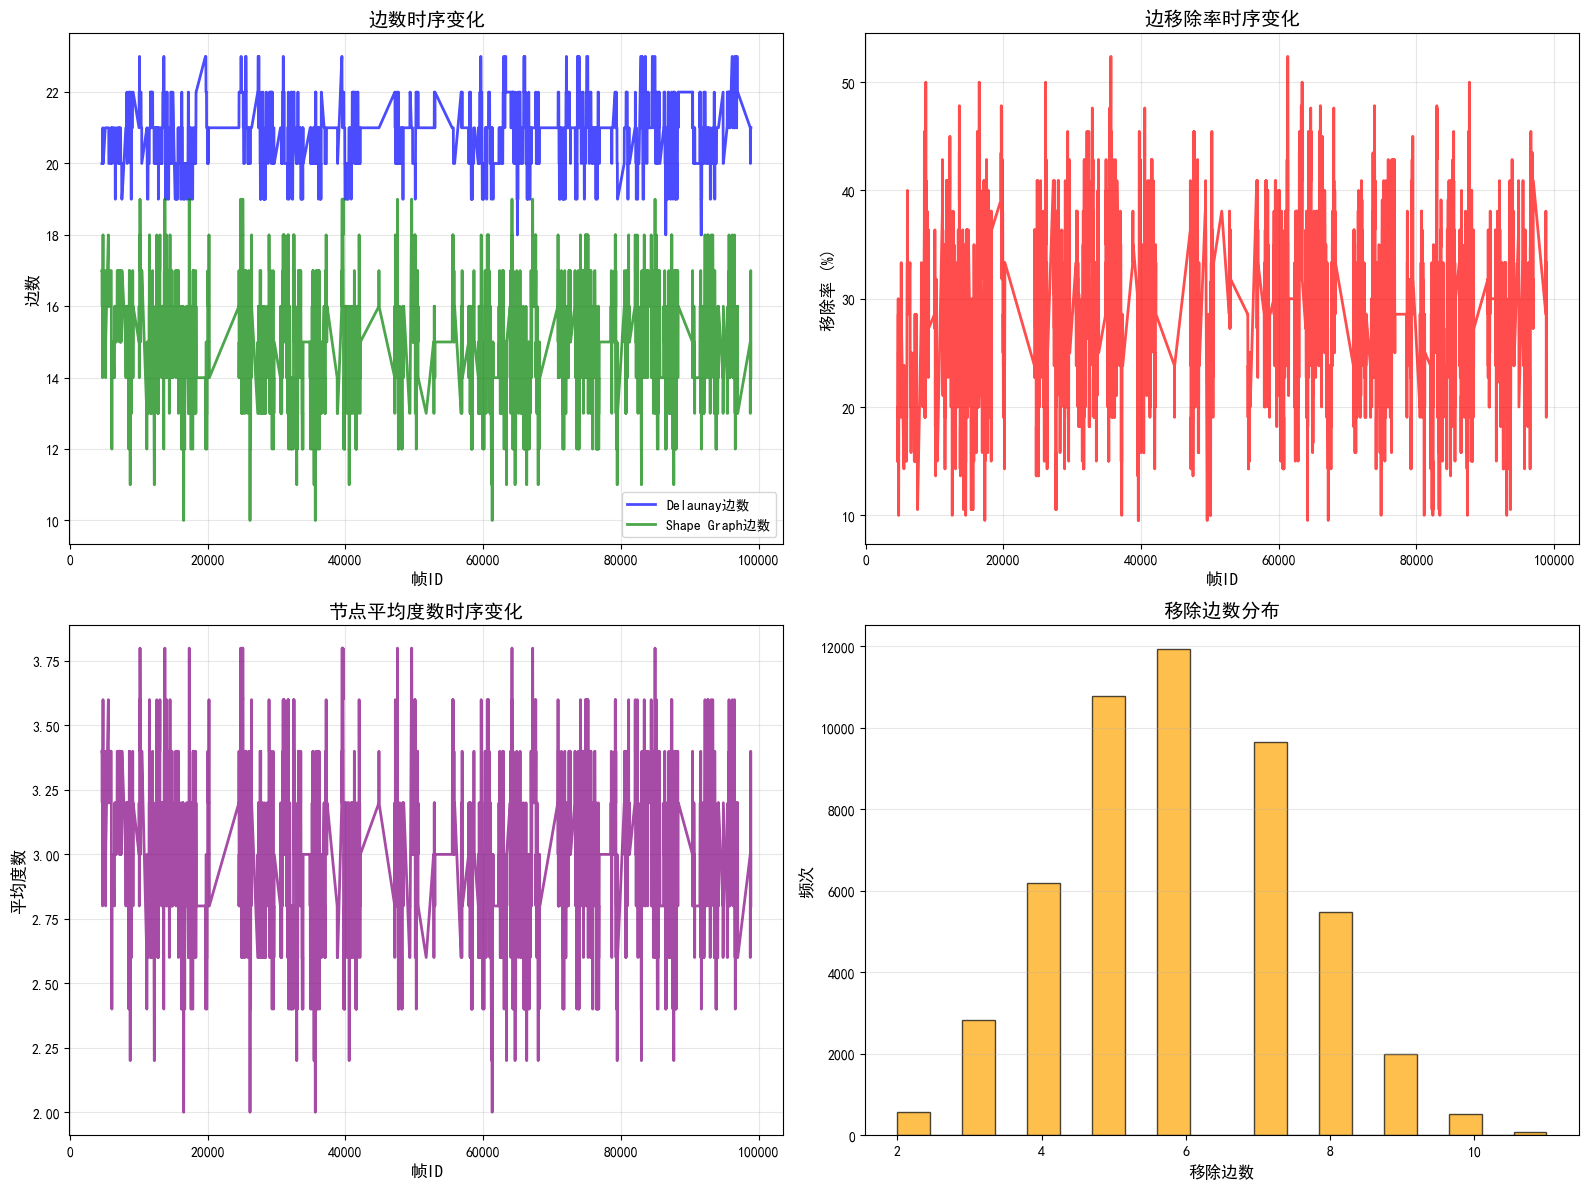

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 边数变化
axes[0, 0].plot(results_df['frame_id'], results_df['num_initial_edges'], 
               'b-', label='Delaunay边数', linewidth=2, alpha=0.7)
axes[0, 0].plot(results_df['frame_id'], results_df['num_final_edges'], 
               'g-', label='Shape Graph边数', linewidth=2, alpha=0.7)
axes[0, 0].set_xlabel('帧ID', fontsize=12)
axes[0, 0].set_ylabel('边数', fontsize=12)
axes[0, 0].set_title('边数时序变化', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. 移除率
axes[0, 1].plot(results_df['frame_id'], results_df['removal_rate'] * 100, 
               'r-', linewidth=2, alpha=0.7)
axes[0, 1].set_xlabel('帧ID', fontsize=12)
axes[0, 1].set_ylabel('移除率 (%)', fontsize=12)
axes[0, 1].set_title('边移除率时序变化', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. 平均度数
axes[1, 0].plot(results_df['frame_id'], results_df['avg_degree'], 
               'purple', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('帧ID', fontsize=12)
axes[1, 0].set_ylabel('平均度数', fontsize=12)
axes[1, 0].set_title('节点平均度数时序变化', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. 移除边数分布
axes[1, 1].hist(results_df['num_removed_edges'], bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('移除边数', fontsize=12)
axes[1, 1].set_ylabel('频次', fontsize=12)
axes[1, 1].set_title('移除边数分布', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'batch_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. 鲁棒性验证

In [8]:
# 鲁棒性验证（使用混合策略识别守门员）
test_frame_id = sample_frames[len(sample_frames) // 2]

# 🔧 混合策略：为测试帧识别守门员
test_goalkeeper_id = identify_goalkeeper(tracking_pl, HOME_TEAM_ID, frame_id=test_frame_id, method='statistical')

# 分离外场球员、守门员和球
field_players, goalkeeper, ball = separate_players_and_ball(
    tracking_pl, HOME_TEAM_ID, test_frame_id, test_goalkeeper_id
)

positions = field_players[['x', 'y']].values

# 添加不同程度的噪声
noise_levels = [0.0, 0.01, 0.02, 0.05]
robustness_results = []

for noise_level in noise_levels:
    noisy_positions = positions + np.random.randn(*positions.shape) * noise_level
    shape_graph, num_removed, num_initial = build_shape_graph(noisy_positions)
    
    robustness_results.append({
        'noise_level': noise_level,
        'num_edges': shape_graph.number_of_edges(),
        'removal_rate': num_removed / num_initial if num_initial > 0 else 0
    })

robustness_df = pd.DataFrame(robustness_results)
print("\n鲁棒性测试结果:")
print(robustness_df)


鲁棒性测试结果:
   noise_level  num_edges  removal_rate
0         0.00         15      0.285714
1         0.01         15      0.285714
2         0.02         15      0.285714
3         0.05         15      0.285714


## 7. 鲁棒性可视化

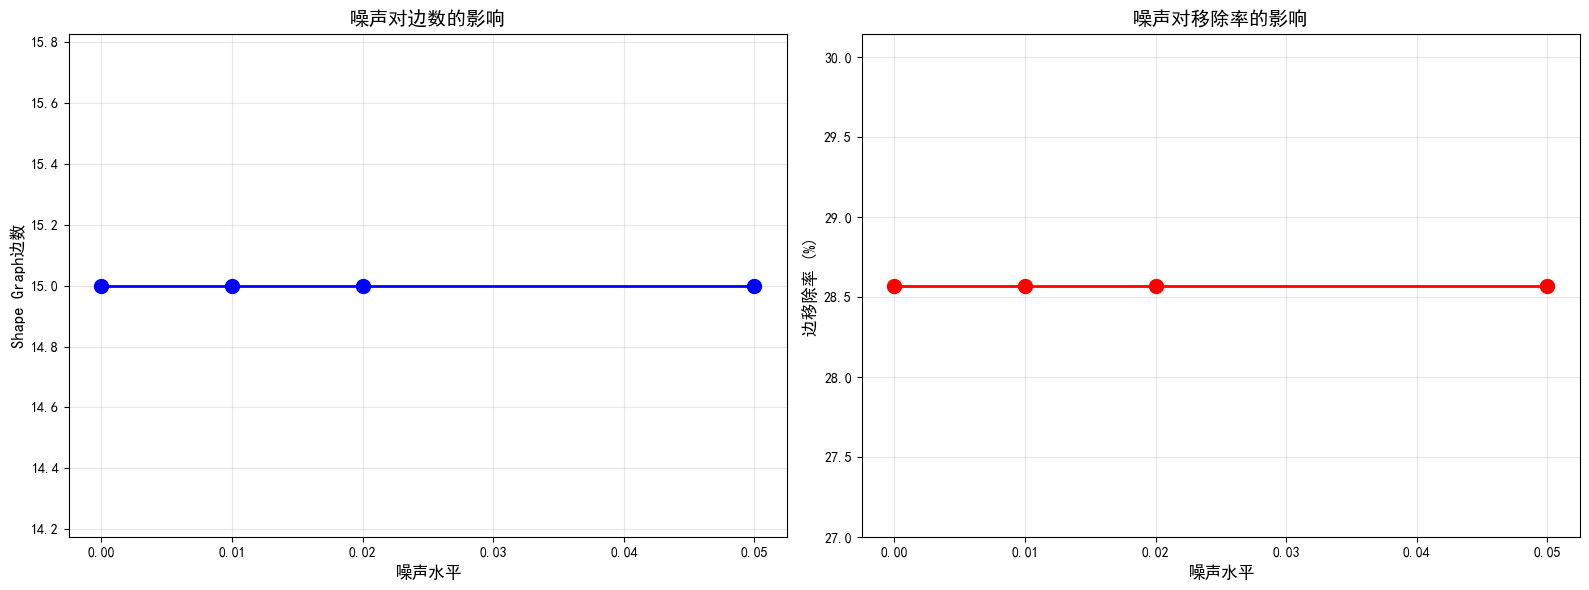

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 边数变化
ax1.plot(robustness_df['noise_level'], robustness_df['num_edges'], 
        'bo-', linewidth=2, markersize=10)
ax1.set_xlabel('噪声水平', fontsize=12)
ax1.set_ylabel('Shape Graph边数', fontsize=12)
ax1.set_title('噪声对边数的影响', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 移除率变化
ax2.plot(robustness_df['noise_level'], robustness_df['removal_rate'] * 100, 
        'ro-', linewidth=2, markersize=10)
ax2.set_xlabel('噪声水平', fontsize=12)
ax2.set_ylabel('边移除率 (%)', fontsize=12)
ax2.set_title('噪声对移除率的影响', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'robustness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. 保存批量处理结果

In [10]:
results_file = OUTPUT_DIR / f'batch_results_{GAME_ID}.csv'
results_df.to_csv(results_file, index=False)
print(f"批量处理结果已保存: {results_file}")

robustness_file = OUTPUT_DIR / f'robustness_results_{GAME_ID}.csv'
robustness_df.to_csv(robustness_file, index=False)
print(f"鲁棒性测试结果已保存: {robustness_file}")

批量处理结果已保存: ..\..\data\morph_test\shape_graphs\batch_results_10517.csv
鲁棒性测试结果已保存: ..\..\data\morph_test\shape_graphs\robustness_results_10517.csv


## 9. 总结

### 完成的工作

1. ✅ 批量处理第1节所有帧的Shape Graph构建
2. ✅ 分析了Shape Graph的时序稳定性
3. ✅ 验证了图表示对噪声的鲁棒性
4. ✅ 保存了批量处理和鲁棒性测试结果

### 关键发现

- Shape Graph通过角度稳定性剪枝有效减少了不稳定的边
- 移除率在不同帧之间保持相对稳定
- 图表示对小幅度噪声具有良好的鲁棒性

### Step 2完成状态

**Step 2: 鲁棒的图表示** 已全部完成，包括:
- 2.1: Delaunay三角剖分
- 2.2: Shape Graph剪枝算法
- 2.3: 批量处理与验证

可以继续进行Step 3的开发。